In [1]:
from neko.core.network import Network
from neko._visual.visualize_network import NetworkVisualizer
import omnipath as op

Define gene list of interest (seeds)

In [2]:
genes = ["SRC", "NOTCH1", "FAK", "CDH1", "CDH2", "VIM", "MAP4K4", "LATS1", "LATS2", "PTK2B"]

Compute network

In [ ]:
new_net1 = Network(genes, resources = 'omnipath')

In [4]:
new_net1.nodes

,Genesymbol,Uniprot,Type
0,SRC,P12931,NaN
1,NOTCH1,P46531,NaN
2,PTK2,Q05397,NaN
3,CDH1,P12830,NaN
4,CDH2,P19022,NaN
5,VIM,P08670,NaN
6,MAP4K4,O95819,NaN
7,LATS1,O95835,NaN
8,LATS2,Q9NRM7,NaN
9,PTK2B,Q14289,NaN


Explore if the nodes are connected without introducing new intermidiate nodes


In [5]:
new_net1.connect_nodes(only_signed=True, consensus_only=True)

Visualize the network

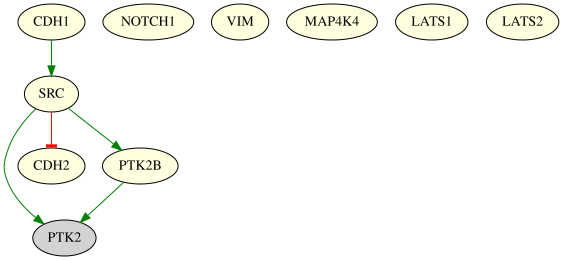

In [6]:
visualizer = NetworkVisualizer(new_net1, color_by='effect', noi=True) #also exported in .pdf in the working directory
visualizer.render()

Connect disconnected nodes by importing intermediate nodes (algorithms BFS or DFS (take + time))

In [7]:
new_net1.complete_connection(maxlen=3, algorithm="bfs", only_signed=True, connect_with_bias=False, consensus=True)

Visualize final network

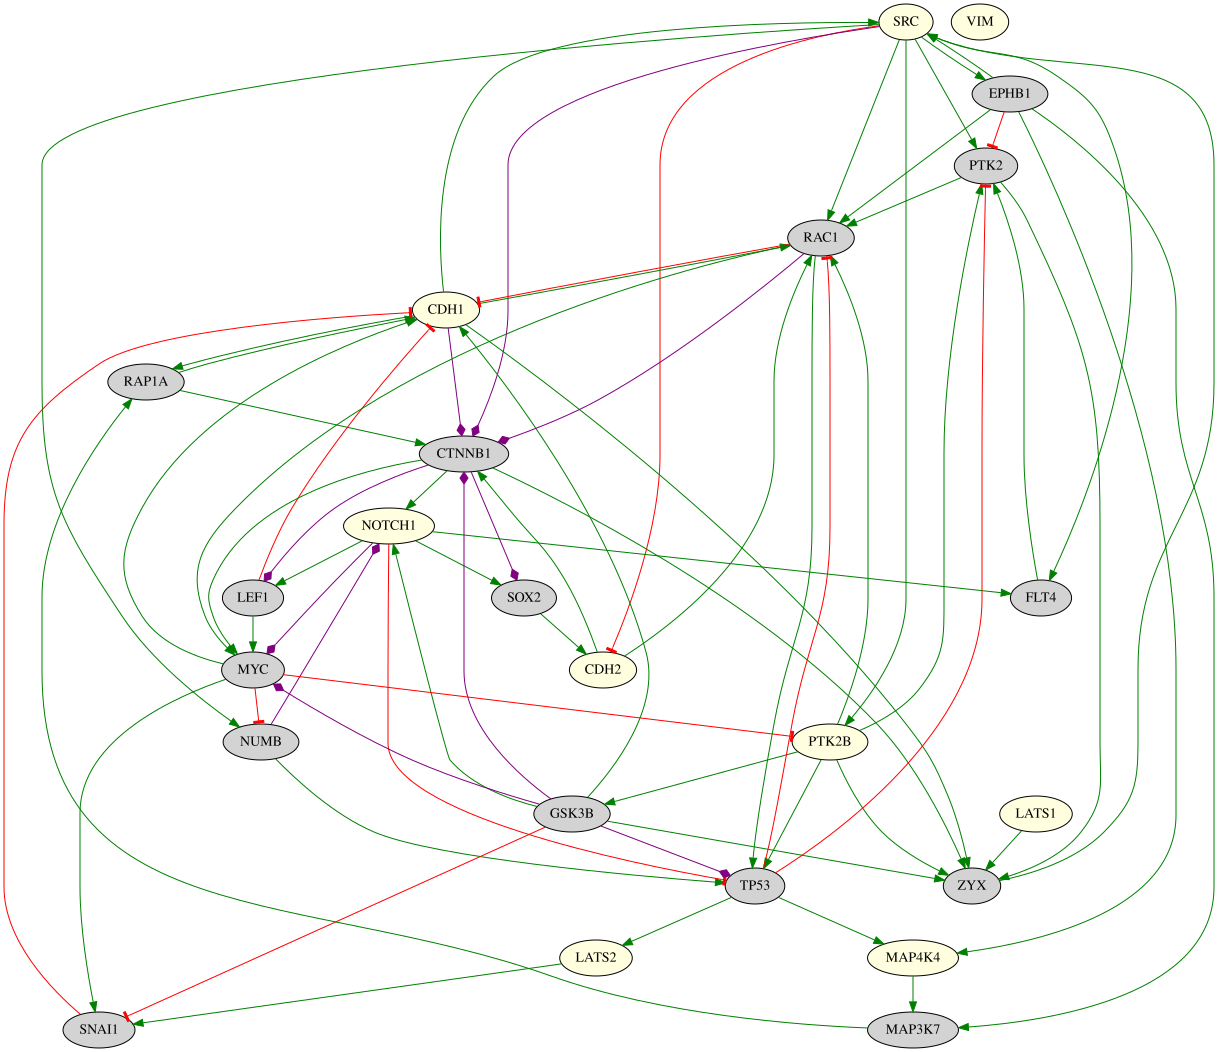

In [8]:
visualizer1 = NetworkVisualizer(new_net1,color_by='effect', noi=True)
visualizer1.render()

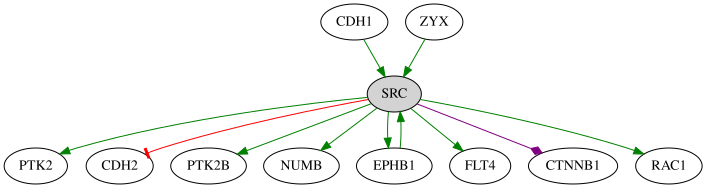

In [9]:
#Visualize a specific nodes and
visualizer1 = NetworkVisualizer(new_net1, predefined_node = "SRC",color_by='effect')
visualizer1.render()

In [10]:
#We can access to the edges of the network
new_net1.edges

,source,target,Type,Effect,References
0,P12931,Q05397,None,stimulation,Adhesome:10085298;Adhesome:10592173;Adhesome:1...
1,P12830,P12931,None,stimulation,ACSN:16039586;ACSN:16099633;ACSN:17143292;ACSN...
2,P12931,P19022,None,inhibition,ACSN:15782139;ACSN:16371504;ACSN:16492141;ACSN...
3,P12931,Q14289,None,stimulation,Adhesome:10329689;Adhesome:10521452;Adhesome:1...
4,Q14289,Q05397,None,stimulation,Adhesome:16760434;HPRD:16760434;KEA:12960434;K...
...,...,...,...,...,...
65,P04637,P63000,None,inhibition,NaN
66,P49841,P01106,None,bimodal,ACSN:10671551;ACSN:11274345;ACSN:12040186;ACSN...
67,P49841,O95863,None,inhibition,ACSN:11967263;ACSN:14663202;ACSN:15020233;ACSN...
68,P63000,P01106,None,stimulation,NaN


INE algorithm: Iterative Neighbor Expansion 

In [11]:
from neko.core.network import Network
from neko._visual.visualize_network import NetworkVisualizer
from neko.inputs import Universe, signor
from neko._annotations.gene_ontology import Ontology
import omnipath as op
import pandas as pd

Define list of genes of interest

In [12]:
genes = ["PIK3CA","MAP2K1","GSK3B","MAPK14","CTNNB1","AKT1","MAP3K7"]
output_nodes_prosurvival = ['CCND1','MYC','TCF7L2']

Create network

In [16]:
new_net = Network(initial_nodes = genes, resources='omnipath')

Connect nodes

The INE algorith connects the input nodes by looking and introducing all their immediate neighbors into the network. If the nodes remain unconnected, the immediate neighbors of the newly introduced nodes are added into the network. The process ends either when a complete network is reached or until the user-specified threshold of expansion steps (i.e., max_len) is specified.

The algorithm also allows the definition of outputs, which are nodes that should be connected to the network with only incoming edges. For instance, these nodes might represent phenotypic markers (e.g., proliferation) of interest.

At the end of the algorithm, any nodes that do not have a source in the edge dataframe and are not in the output node are removed..

In [17]:
new_net.connect_as_atopo(max_len=1, strategy="radial",outputs=output_nodes_prosurvival)

In [18]:
new_net.edges

,source,target,Type,Effect,References
0,Q02750,P27361,None,stimulation,ACSN:7565670;ACSN:7731720;ACSN:8226933;ACSN:83...
1,Q02750,P42336,None,stimulation,NaN
2,Q02750,O00329,None,stimulation,NaN
3,Q02750,P28482,None,stimulation,CancerCellMap:11251083;CancerCellMap:12644307;...
4,Q02750,Q8WU20,None,inhibition,NaN
...,...,...,...,...,...
847,P63000,P24385,None,stimulation,NaN
848,P63000,P01106,None,stimulation,NaN
852,Q92793,P24385,None,inhibition,NaN
853,Q92793,P01106,None,inhibition,ACSN:15279786;ACSN:15522869;ACSN:17303408;ACSN...


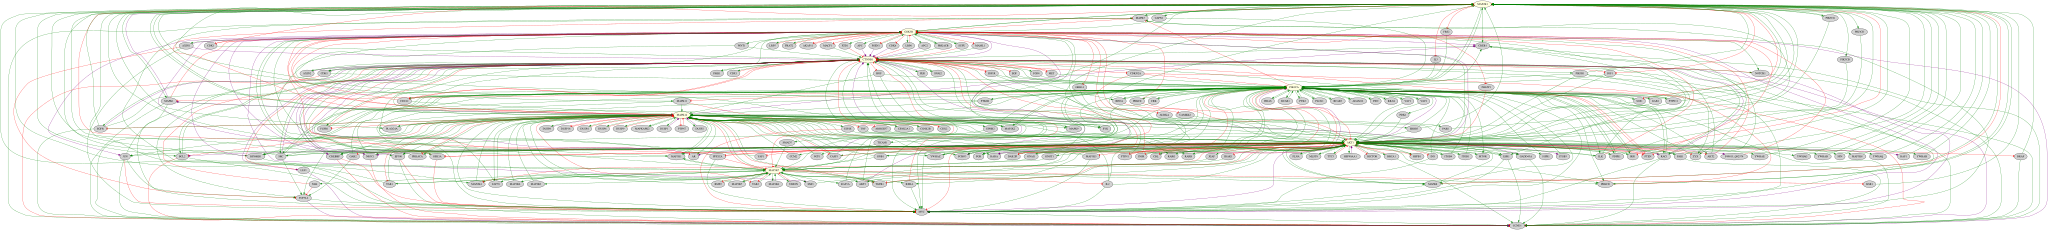

In [19]:
visualizer = NetworkVisualizer(new_net, color_by='effect', noi=True)
visualizer.render()

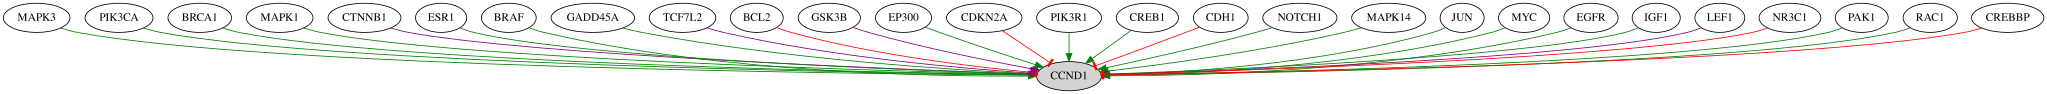

In [20]:
visualizer = NetworkVisualizer(new_net, color_by='effect', noi=True, predefined_node="CCND1")
visualizer.render()

### Connect to upstream components

In [21]:
from neko.core.network import Network
from neko._visual.visualize_network import NetworkVisualizer
from neko.inputs import Universe
from neko._annotations.gene_ontology import Ontology
import omnipath as op

Define gene list

In [22]:
genes = ["SRC", "NOTCH1", "CDH1", "CDH2", "VIM", "LATS1", "LATS2"]

Create network

In [24]:
new_net1 = Network(genes, resources='omnipath')

Connect nodes to upstream regulators

The connect_to_upstream_nodes looks for the regulators of each of the input nodes, and ranks each of the regulators based on the number of the input nodes they regulate.

The rank argument refers to the number of the ranked regulators that should be included in the network The depth argument refers to how many steps away from the input nodes the algorithm should go. The higher the number the more regulatory layers will be included in the final network.

In [25]:
new_net1.connect_to_upstream_nodes(rank = 1, depth=2)

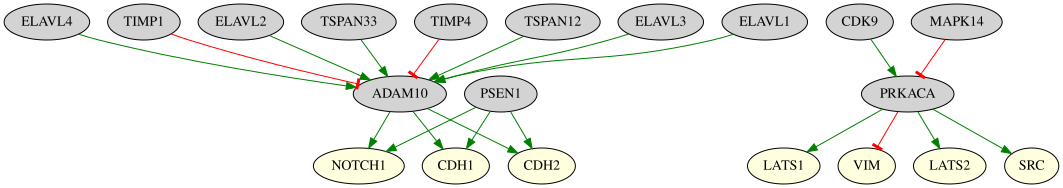

In [26]:
visualizer = NetworkVisualizer(new_net1, color_by='effect', noi=True)
visualizer.render()

### Connect to downstream Gene Ontology terms

In [27]:
from neko.core.network import Network
from neko._visual.visualize_network import NetworkVisualizer
from neko.inputs import Universe
from neko._annotations.gene_ontology import Ontology
import omnipath as op

Build network and connect nodes

In [28]:
genes = ["SRC", "NOTCH1", "FAK"]
new_net1 = Network(genes, resources = 'omnipath')
new_net1.connect_nodes(only_signed=True, consensus_only=True)

Connect to Gene Ontology (GO) term

In [29]:
new_net1.connect_genes_to_phenotype(id_accession="GO:0001837", phenotype="epithelial to mesenchymal transition", only_signed=True, compress=True, maxlen=1)

Start requesting genes from Gene Ontology
Fetching from:  https://golr-aux.geneontology.io/solr/select?defType=edismax&qt=standard&indent=on&wt=csv&rows=100000&start=0&fl=bioentity_label&facet=true&facet.mincount=1&facet.sort=count&json.nl=arrarr&facet.limit=25&hl=true&hl.simple.pre=%3Cem%20class=%22hilite%22%3E&hl.snippets=1000&csv.encapsulator=&csv.separator=%09&csv.header=false&csv.mv.separator=%7C&fq=document_category:%22annotation%22&fq=isa_partof_closure:%22GO:0001837%22&fq=taxon_subset_closure_label:%22Homo%20sapiens%22&fq=type:%22protein%22&fq=annotation_class_label:%22epithelial%20to%20mesenchymal%20transition%22&facet.field=aspect&facet.field=taxon_subset_closure_label&facet.field=type&facet.field=evidence_subset_closure_label&facet.field=regulates_closure_label&facet.field=isa_partof_closure_label&facet.field=annotation_class_label&facet.field=qualifier&facet.field=annotation_extension_class_closure_label&facet.field=assigned_by&facet.field=panther_family_label&q=*:*
Done
St

Visualize network

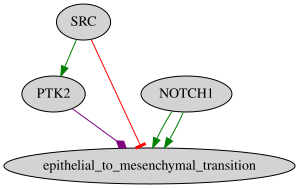

In [30]:
#Visualize network
visualizer1 = NetworkVisualizer(new_net1, color_by='effect')
visualizer1.render()